# Predictive Analytics: Neural Network - Advanced Baseline v2

Note: theoretically we would need to either encode the spatial feature (i. e. community area) or train a separate model for each spatial unit. Otherwise the feature "community_area" is a continuous numeric feature!

Like v1 but with model architecture from baseline to check if log1p is helping or not

=> v2 is better than v1 and baseline -> log1p should be helpful

In [1]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import math
import matplotlib.pyplot as plt

## Preparations

In [2]:
# "Settings" / Decisions for the training data

TRAINING_DATA_PATH = "../data/train_test_data/train.parquet"
VAL_DATA_PATH = "../data/train_test_data/val.parquet"

MODEL_PATH = "../models"

# Target and feature selection
TARGET_COL = "trip_count"
EXCLUDE_COLS = [
    TARGET_COL,
    "datetime_hour",      # real timestamp would lead to much leakage
    "_split_bucket",      # only used for splitting
    "month", # cyclic feature is used instead
    "weekday", # cyclic feature is used instead
    "hour", # cyclic feature is used instead
    # all other taxi data columns must be excluded to prevent leakage
    "trip_seconds_sum",
    "trip_seconds_mean",
    "trip_seconds_min",
    "trip_seconds_max",
    "trip_miles_sum",
    "trip_miles_mean",
    "trip_miles_min",
    "trip_miles_max",
    "fare_sum",
    "fare_mean",
    "fare_min",
    "fare_max",
    "tips_sum",
    "tips_mean",
    "tips_min",
    "tips_max",
    "tolls_sum",
    "tolls_mean",
    "tolls_min",
    "tolls_max",
    "extras_sum",
    "extras_mean",
    "extras_min",
    "extras_max",
    "trip_total_sum",
    "trip_total_mean",
    "trip_total_min",
    "trip_total_max",
    "most_common_payment_type",
]

        

### Load the data and select features and target

In [3]:
# Load the tranining data
train_df = pl.scan_parquet(TRAINING_DATA_PATH)
val_df = pl.scan_parquet(VAL_DATA_PATH)

# Create X and Y data
feature_cols = [
    col for col in train_df.collect_schema().names()
    if col not in EXCLUDE_COLS
]

X_train = train_df.select(feature_cols).collect()
y_train = train_df.select(TARGET_COL).collect()

X_val = val_df.select(feature_cols).collect()
y_val = val_df.select(TARGET_COL).collect()

print("Features: ", X_train.schema)
print("Target: ", y_train.schema)

Features:  Schema([('month_sin', Float64), ('month_cos', Float64), ('weekday_sin', Float64), ('weekday_cos', Float64), ('hour_sin', Float64), ('hour_cos', Float64), ('tmpc', Float64), ('relh', Float64), ('sknt', Float64), ('vsby', Float64), ('p01m', Float64), ('skyc1_BKN', Int8), ('skyc1_CLR', Int8), ('skyc1_FEW', Int8), ('skyc1_OVC', Int8), ('skyc1_SCT', Int8), ('skyc1_VV ', Int8), ('date', Date), ('is_holiday', Int8), ('community_area', Int64), ('food_drink', Float64), ('landmark', Float64), ('shop', Float64), ('train_station', Float64)])
Target:  Schema([('trip_count', UInt32)])


Impotant, check datatype of features and target. Everything should be numerical. We already applied encoding to categorical features (e. g. cloud coverage), therefore all features are numerical.

### Scale the train data

Important, the scaler is only fitted on X_train to prevent data leakage

In [ ]:
# transform to numpy as it works best with scaler
X_train_np = X_train.to_numpy()
X_val_np = X_val.to_numpy()

# fit scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_np) # fit only called on train
X_val_scaled = scaler.transform(X_val_np) # only transformed, not fitted!

# prepare target and features
# log1p transformation
y_train_np = np.log1p(y_train.to_numpy()).astype("float32")
y_val_np = np.log1p(y_val.to_numpy()).astype("float32")
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")

print(X_train_scaled.shape)
print(y_train_np.shape)

print(X_val_scaled.shape)
print(y_val_np.shape)

(1101002, 24)
(1101002, 1)
(236011, 24)
(236011, 1)


### PyTorch Dataset and DataLoader

In [5]:
# Convert to pytorch tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

print(X_val_tensor.shape)
print(y_val_tensor.shape)

# Tensor dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

torch.Size([1101002, 24])
torch.Size([1101002, 1])
torch.Size([236011, 24])
torch.Size([236011, 1])


**BATCH_SIZE** we start with a standard batch_size of 1024 as we have a lot of training data and a smaller batch_size would lead to too many updates in each epoche

Possible, other used batch_sizes could be: 32, 64, 128, 256, 512, 1024, 2048

In [6]:
# Create the data loader
BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test
X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)
print(y_batch.shape)

torch.Size([1024, 24])
torch.Size([1024, 1])


## Advanced Baseline v1

In [7]:
# model needs the number of features
input_dim = X_train_tensor.shape[1]

print("Input Features:", input_dim)

Input Features: 24


### Model architecture


In [8]:
class TaxiDemandAdvancedNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [10]:
# initialise model
model = TaxiDemandAdvancedNN(
    input_dim=input_dim,
)
print(model)

TaxiDemandAdvancedNN(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [11]:
# Test with one batch
X_batch, y_batch = next(iter(train_loader))

y_pred = model(X_batch)

print("Input batch:", X_batch.shape)
print("Prediction batch:", y_pred.shape)
print("Target batch:", y_batch.shape)

Input batch: torch.Size([1024, 24])
Prediction batch: torch.Size([1024, 1])
Target batch: torch.Size([1024, 1])


There it important to check that the shape is the batch_size and the right dimension, i. e. number of features / target

In [12]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = model.to(device)

Using device: mps


### Loss function and optimizer

As loss we start with MSELoss, which means that larger errors are larger penalized. And we use ADAM as optimizer with a learning rate of 0.001 as of now.

Options for further models:
- L1Loss(): more similar to MAE

In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

### Trainingsloop and Validation

In [14]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    
    total_loss = 0.0
    total_samples = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 1. Alte Gradienten löschen
        optimizer.zero_grad()
        
        # 2. Forward Pass
        y_pred = model(X_batch)
        
        # 3. Loss berechnen
        loss = criterion(y_pred, y_batch)
        
        # 4. Backpropagation
        loss.backward()
        
        # 5. Gewichte updaten
        optimizer.step()
        
        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
    
    avg_loss = total_loss / total_samples
    return avg_loss

def evaluate(model, val_loader, criterion, device):
    model.eval()
    
    total_loss = 0.0
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)

            y_batch = y_batch.view_as(y_pred)

            loss = criterion(y_pred, y_batch)
            
            # back transformation
            y_pred_original = torch.expm1(y_pred)
            y_true_original = torch.expm1(y_batch)

            y_pred_original = torch.clamp(y_pred_original, min=0)
            
            batch_size = X_batch.size(0)
            
            total_loss += loss.item() * batch_size

            # MAE/RMSE on original scaled data
            total_absolute_error += torch.sum(
                torch.abs(y_pred_original - y_true_original)
            ).item()

            total_squared_error += torch.sum(
                (y_pred_original - y_true_original) ** 2
            ).item()

            total_samples += batch_size
    
    avg_loss = total_loss / total_samples
    mae = total_absolute_error / total_samples
    rmse = (total_squared_error / total_samples) ** 0.5
    
    return avg_loss, mae, rmse

### Start trainingsloop

We use checkpoint to store the models parameter after each epoche

In [15]:
EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 0


train_losses = []
val_losses = []
val_maes = []
val_rmses = []


best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )
    
    val_loss, val_mae, val_rmse = evaluate(
        model=model,
        val_loader=val_loader,
        criterion=criterion,
        device=device
    )
    
    if not math.isfinite(train_loss) or not math.isfinite(val_loss):
        print(
            f"Stopping early: non-finite loss detected | "
            f"Train Loss: {train_loss} | Val Loss: {val_loss}"
        )
        break
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    val_rmses.append(val_rmse)
    
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"Val RMSE: {val_rmse:.4f}"
    )
    
    # Checkpoint nach jeder Epoche speichern
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "input_dim": input_dim,
        "batch_size": BATCH_SIZE,
    }
    
    checkpoint_path = Path(MODEL_PATH) / f"advanced_baseline_v2_NN_epoch_{epoch + 1:03d}.pt"
    torch.save(checkpoint, checkpoint_path)
    
    print(f"Saved checkpoint: {checkpoint_path}")
    
    # Prüfen, ob sich das Modell verbessert hat
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        
        best_checkpoint_path = Path(MODEL_PATH) / "advanced_baseline_v2_NN_best_model.pt"
        torch.save(checkpoint, best_checkpoint_path)
        
        print(f"Saved new best model: {best_checkpoint_path}")
    
    else:
        epochs_without_improvement += 1
        
        print(
            f"No improvement for {epochs_without_improvement}/"
            f"{PATIENCE} epochs"
        )
        
        if epochs_without_improvement >= PATIENCE:
            print(
                f"Early stopping after {epoch + 1} epochs. "
                f"Best Val Loss: {best_val_loss:.4f}"
            )
            break

Epoch 1/100 | Train Loss: 0.4514 | Val Loss: 0.3081 | Val MAE: 4.1659 | Val RMSE: 18.3501
Saved checkpoint: ../models/advanced_baseline_v2_NN_epoch_001.pt
Saved new best model: ../models/advanced_baseline_v2_NN_best_model.pt
Epoch 2/100 | Train Loss: 0.2581 | Val Loss: 0.2277 | Val MAE: 3.2362 | Val RMSE: 13.6614
Saved checkpoint: ../models/advanced_baseline_v2_NN_epoch_002.pt
Saved new best model: ../models/advanced_baseline_v2_NN_best_model.pt
Epoch 3/100 | Train Loss: 0.2155 | Val Loss: 0.2106 | Val MAE: 2.9785 | Val RMSE: 12.6903
Saved checkpoint: ../models/advanced_baseline_v2_NN_epoch_003.pt
Saved new best model: ../models/advanced_baseline_v2_NN_best_model.pt
Epoch 4/100 | Train Loss: 0.2053 | Val Loss: 0.2030 | Val MAE: 2.7565 | Val RMSE: 11.1450
Saved checkpoint: ../models/advanced_baseline_v2_NN_epoch_004.pt
Saved new best model: ../models/advanced_baseline_v2_NN_best_model.pt
Epoch 5/100 | Train Loss: 0.2008 | Val Loss: 0.1987 | Val MAE: 2.8007 | Val RMSE: 11.5770
Saved chec

KeyboardInterrupt: 

### Load best model after training

In [29]:
checkpoint = torch.load(
    Path(MODEL_PATH) / "advanced_baseline_v2_NN_best_model.pt",
    map_location=device
)

model = TaxiDemandAdvancedNN(input_dim=checkpoint["input_dim"])
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Loaded epoch:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["val_loss"])
print("Validation MAE:", checkpoint["val_mae"])
print("Validation RMSE:", checkpoint["val_rmse"])

Loaded epoch: 42
Validation Loss: 0.17982670240780624
Validation MAE: 2.535297228820861
Validation RMSE: 10.295166200761964


## Analyse model performance

In [34]:
def collect_predictions(
    model,
    data_loader,
    device,
    clip_negative_predictions: bool = True,
):
    """
    Erstellt Predictions für ein PyTorch-Modell und gibt eine Polars-Auswertungstabelle zurück.

    Parameters
    ----------
    model : torch.nn.Module
        Trainiertes PyTorch-Modell.
    data_loader : torch.utils.data.DataLoader
        DataLoader, z. B. val_loader. Wichtig: shuffle=False.
    device : torch.device
        Device, z. B. cpu, cuda oder mps.
    clip_negative_predictions : bool
        Wenn True, werden negative Predictions auf 0 gesetzt.
        Sinnvoll bei trip_count, da Demand nicht negativ sein kann.

    Returns
    -------
    pl.DataFrame
        Tabelle mit y_true, y_pred, residual, abs_error, squared_error.
    """
    
    model.eval()
    
    y_true_list = []
    y_pred_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            
            y_pred = model(X_batch)
            
            y_true_list.append(y_batch.cpu().numpy().reshape(-1))
            y_pred_list.append(y_pred.cpu().numpy().reshape(-1))
    
    y_true_log = np.concatenate(y_true_list)
    y_pred_log = np.concatenate(y_pred_list)

    # Rücktransformation von log1p-Skala auf originale trip_count-Skala
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    
    if clip_negative_predictions:
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
    
    eval_df = pl.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
    }).with_columns([
        (pl.col("y_true") - pl.col("y_pred")).alias("residual"),
        (pl.col("y_true") - pl.col("y_pred")).abs().alias("abs_error"),
        ((pl.col("y_true") - pl.col("y_pred")) ** 2).alias("squared_error"),
    ])
    
    return eval_df


In [35]:
val_eval_df = collect_predictions(
    model=model,
    data_loader=val_loader,
    device=device,
    clip_negative_predictions=True,
)

print(val_eval_df.shape)
val_eval_df.head()

(236011, 5)


y_true,y_pred,residual,abs_error,squared_error
f32,f32,f32,f32,f32
0.0,0.116851,-0.116851,0.116851,0.013654
0.0,0.405714,-0.405714,0.405714,0.164604
1.0,0.217496,0.782504,0.782504,0.612312
0.0,0.014031,-0.014031,0.014031,0.000197
0.0,0.222131,-0.222131,0.222131,0.049342


In [36]:
def compute_regression_metrics(
    eval_df: pl.DataFrame,
    zero_threshold: float = 0.0,
    peak_quantile: float = 0.90,
) -> pl.DataFrame:
    """
    Berechnet zentrale Regressionsmetriken für Demand Forecasting.

    Erwartet Spalten:
    - y_true
    - y_pred
    - residual
    - abs_error
    - squared_error
    """

    y_true = eval_df["y_true"].to_numpy()
    y_pred = eval_df["y_pred"].to_numpy()

    # Sicherheit: nur finite Werte verwenden
    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite_mask]
    y_pred = y_pred[finite_mask]

    errors = y_true - y_pred
    abs_errors = np.abs(errors)
    squared_errors = errors ** 2

    n = len(y_true)

    mae = abs_errors.mean()
    mse = squared_errors.mean()
    rmse = np.sqrt(mse)

    # residual = y_true - y_pred
    # positiv bedeutet: Modell unterschätzt im Schnitt
    mean_residual = errors.mean()

    # R²
    ss_res = np.sum(squared_errors)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Zero / Non-Zero Analyse
    zero_mask = y_true <= zero_threshold
    nonzero_mask = y_true > zero_threshold

    zero_share = zero_mask.mean()
    nonzero_share = nonzero_mask.mean()

    zero_mae = np.mean(abs_errors[zero_mask]) if zero_mask.any() else np.nan
    nonzero_mae = np.mean(abs_errors[nonzero_mask]) if nonzero_mask.any() else np.nan

    zero_rmse = np.sqrt(np.mean(squared_errors[zero_mask])) if zero_mask.any() else np.nan
    nonzero_rmse = np.sqrt(np.mean(squared_errors[nonzero_mask])) if nonzero_mask.any() else np.nan

    # Peak Demand: oberes Quantil der Non-Zero-Fälle
    if nonzero_mask.any():
        peak_threshold = np.quantile(y_true[nonzero_mask], peak_quantile)
        peak_mask = y_true >= peak_threshold
        peak_mae = np.mean(abs_errors[peak_mask])
        peak_rmse = np.sqrt(np.mean(squared_errors[peak_mask]))
        peak_share = peak_mask.mean()
    else:
        peak_threshold = np.nan
        peak_mae = np.nan
        peak_rmse = np.nan
        peak_share = np.nan

    metrics_df = pl.DataFrame({
        "metric": [
            "n_samples",
            "mae",
            "mse",
            "rmse",
            "r2",
            "mean_residual_true_minus_pred",
            "zero_share",
            "nonzero_share",
            "zero_mae",
            "nonzero_mae",
            "zero_rmse",
            "nonzero_rmse",
            "peak_threshold",
            "peak_share",
            "peak_mae",
            "peak_rmse",
        ],
        "value": [
            float(n),
            float(mae),
            float(mse),
            float(rmse),
            float(r2),
            float(mean_residual),
            float(zero_share),
            float(nonzero_share),
            float(zero_mae),
            float(nonzero_mae),
            float(zero_rmse),
            float(nonzero_rmse),
            float(peak_threshold),
            float(peak_share),
            float(peak_mae),
            float(peak_rmse),
        ]
    })

    return metrics_df

In [37]:
val_metrics_df = compute_regression_metrics(val_eval_df)

print(val_metrics_df)

shape: (16, 2)
┌────────────────┬────────────┐
│ metric         ┆ value      │
│ ---            ┆ ---        │
│ str            ┆ f64        │
╞════════════════╪════════════╡
│ n_samples      ┆ 236011.0   │
│ mae            ┆ 2.535297   │
│ mse            ┆ 105.990433 │
│ rmse           ┆ 10.295165  │
│ r2             ┆ 0.913522   │
│ …              ┆ …          │
│ nonzero_rmse   ┆ 13.642713  │
│ peak_threshold ┆ 26.000002  │
│ peak_share     ┆ 0.056497   │
│ peak_mae       ┆ 27.806925  │
│ peak_rmse      ┆ 42.146786  │
└────────────────┴────────────┘


In [38]:
def plot_regression_diagnostics(
    eval_df: pl.DataFrame,
    sample_size: int = 100_000,
    n_bins: int = 50,
):
    """
    Erstellt zentrale Diagnoseplots für ein Regressionsmodell.

    Erwartet Spalten:
    - y_true
    - y_pred
    - residual
    - abs_error
    - squared_error
    """

    # In NumPy umwandeln
    y_true = eval_df["y_true"].to_numpy()
    y_pred = eval_df["y_pred"].to_numpy()
    residual = eval_df["residual"].to_numpy()
    abs_error = eval_df["abs_error"].to_numpy()

    # Nur finite Werte verwenden
    finite_mask = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & np.isfinite(residual)
        & np.isfinite(abs_error)
    )

    y_true = y_true[finite_mask]
    y_pred = y_pred[finite_mask]
    residual = residual[finite_mask]
    abs_error = abs_error[finite_mask]

    # Für Scatter ggf. samplen, sonst wird es bei Millionen Zeilen unlesbar/langsam
    n = len(y_true)

    if n > sample_size:
        rng = np.random.default_rng(seed=42)
        sample_idx = rng.choice(n, size=sample_size, replace=False)

        y_true_sample = y_true[sample_idx]
        y_pred_sample = y_pred[sample_idx]
    else:
        y_true_sample = y_true
        y_pred_sample = y_pred

    # --------------------------------------------------
    # Plot 1: Actual vs Predicted
    # --------------------------------------------------
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true_sample, y_pred_sample, alpha=0.2, s=8)

    max_value = max(y_true_sample.max(), y_pred_sample.max())
    plt.plot([0, max_value], [0, max_value], linestyle="--")

    plt.xlabel("Actual trip_count")
    plt.ylabel("Predicted trip_count")
    plt.title("Actual vs. Predicted")
    plt.grid(True)
    plt.show()

  # --------------------------------------------------
    # Plot 2: Residual Histogram - gezoomt
    # --------------------------------------------------
    residual_lower = np.quantile(residual, 0.01)
    residual_upper = np.quantile(residual, 0.99)

    plt.figure(figsize=(9, 5))
    plt.hist(
        residual,
        bins=n_bins,
        range=(residual_lower, residual_upper)
    )
    plt.axvline(0, linestyle="--")

    plt.xlabel("Residual: y_true - y_pred")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution, zoomed to 1st–99th percentile")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------
    # Plot 3: Distribution y_true vs y_pred - gezoomt
    # --------------------------------------------------
    upper = np.quantile(
        np.concatenate([y_true, y_pred]),
        0.99
    )

    plt.figure(figsize=(9, 5))
    plt.hist(
        y_true,
        bins=n_bins,
        range=(0, upper),
        alpha=0.5,
        label="Actual"
    )
    plt.hist(
        y_pred,
        bins=n_bins,
        range=(0, upper),
        alpha=0.5,
        label="Predicted"
    )

    plt.xlabel("trip_count")
    plt.ylabel("Frequency")
    plt.title("Distribution: Actual vs. Predicted, zoomed to 99th percentile")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------
    # Plot 4: MAE nach Demand-Buckets
    # --------------------------------------------------
    bucket_df = (
        pl.DataFrame({
            "y_true": y_true,
            "abs_error": abs_error,
        })
        .with_columns(
            pl.when(pl.col("y_true") == 0).then(pl.lit("0"))
            .when(pl.col("y_true") <= 1).then(pl.lit("1"))
            .when(pl.col("y_true") <= 3).then(pl.lit("2-3"))
            .when(pl.col("y_true") <= 5).then(pl.lit("4-5"))
            .when(pl.col("y_true") <= 10).then(pl.lit("6-10"))
            .when(pl.col("y_true") <= 20).then(pl.lit("11-20"))
            .otherwise(pl.lit(">20"))
            .alias("demand_bucket")
        )
        .group_by("demand_bucket")
        .agg([
            pl.len().alias("n_rows"),
            pl.col("abs_error").mean().alias("mae"),
            pl.col("y_true").mean().alias("avg_y_true"),
        ])
    )

    bucket_order = ["0", "1", "2-3", "4-5", "6-10", "11-20", ">20"]

    bucket_df = (
        bucket_df
        .with_columns(
            pl.col("demand_bucket")
            .replace({bucket: i for i, bucket in enumerate(bucket_order)})
            .cast(pl.Int64)
            .alias("bucket_order")
        )
        .sort("bucket_order")
    )

    bucket_labels = bucket_df["demand_bucket"].to_list()
    bucket_mae = bucket_df["mae"].to_numpy()

    plt.figure(figsize=(9, 5))
    plt.bar(bucket_labels, bucket_mae)

    plt.xlabel("Actual Demand Bucket")
    plt.ylabel("MAE")
    plt.title("MAE by Actual Demand Bucket")
    plt.grid(True, axis="y")
    plt.show()

    return bucket_df

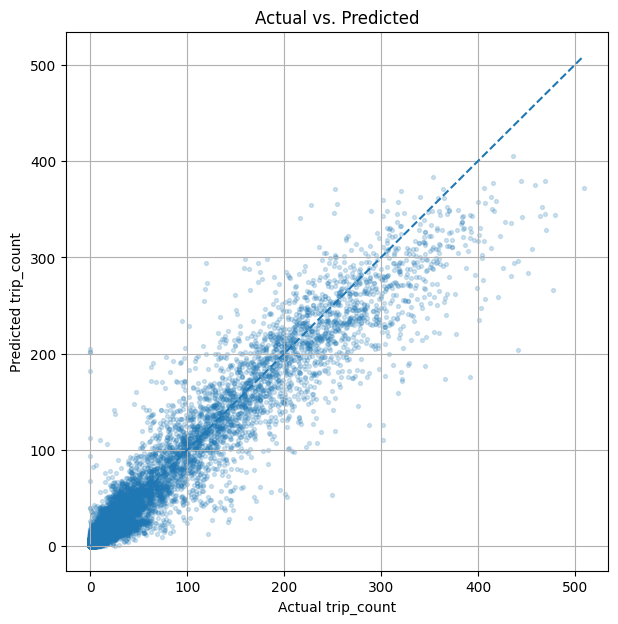

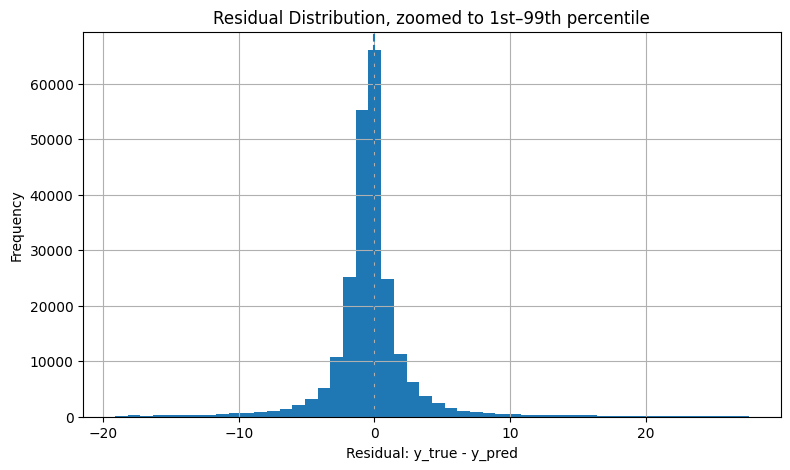

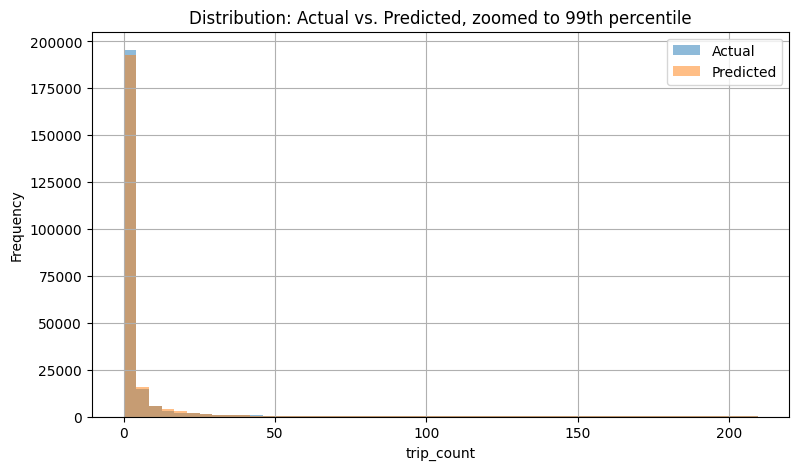

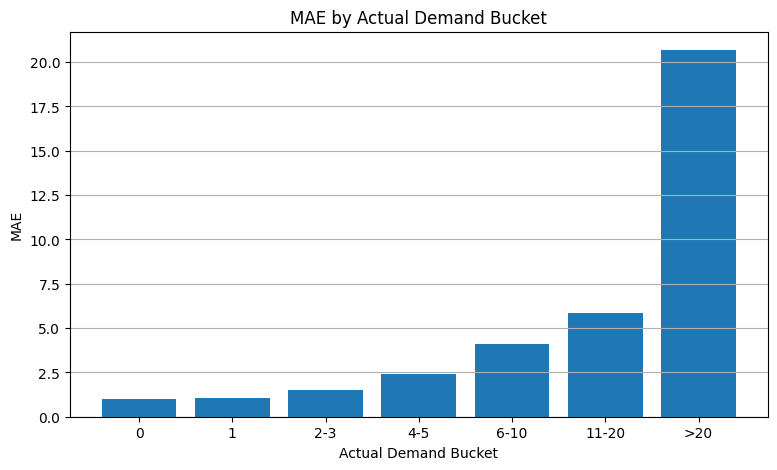

shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 103526 ┆ 0.973703  ┆ 0.0        ┆ 0            │
│ 1             ┆ 46118  ┆ 1.075802  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 37565  ┆ 1.484132  ┆ 2.360495   ┆ 2            │
│ 4-5           ┆ 13616  ┆ 2.392002  ┆ 4.397106   ┆ 3            │
│ 6-10          ┆ 12486  ┆ 4.081517  ┆ 7.517059   ┆ 4            │
│ 11-20         ┆ 7379   ┆ 5.855084  ┆ 14.667028  ┆ 5            │
│ >20           ┆ 15321  ┆ 20.681942 ┆ 105.477776 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘


In [78]:
bucket_eval_df = plot_regression_diagnostics(
    eval_df=val_eval_df,
    sample_size=100_000,
    n_bins=50,
)

print(bucket_eval_df)